<a href="https://colab.research.google.com/github/Prerit-Bhagat/Clustering/blob/main/Clustering_Algorithms.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


📊 All Clustering Results:
        Algorithm     Preprocessing  Clusters  Silhouette  Calinski-Harabasz  \
0          KMeans          Original         2    0.681046         513.924546   
1   Agglomerative          Original         2    0.686735         502.821564   
2          KMeans          Original         3    0.551192         561.593732   
3   Agglomerative          Original         3    0.554324         558.058041   
4          KMeans          Original         4    0.497643         529.529095   
5   Agglomerative          Original         4    0.488967         515.078906   
6          KMeans          Original         5    0.493080         495.243414   
7   Agglomerative          Original         5    0.484383         488.484904   
8       MeanShift          Original         2    0.685788         509.703427   
9          KMeans      Standardized         2    0.581750         251.349339   
10  Agglomerative      Standardized         2    0.577035         240.245665   
11         KM

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.11/dist-packages/matplotlib/pyplot.py'>

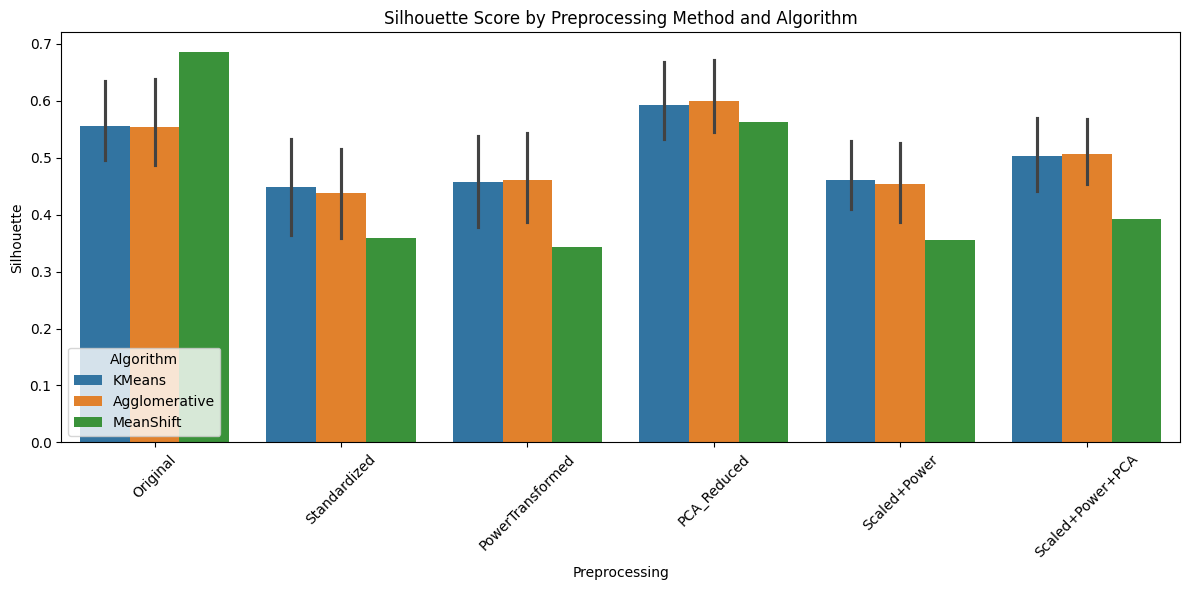

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, MeanShift, AgglomerativeClustering, estimate_bandwidth
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# Load the Iris dataset into a DataFrame
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

# Define preprocessing techniques
preprocessing_options = {
    "Original": lambda X: X,
    "Standardized": lambda X: StandardScaler().fit_transform(X),
    "PowerTransformed": lambda X: PowerTransformer().fit_transform(X),
    "PCA_Reduced": lambda X: PCA(n_components=2).fit_transform(X),
    "Scaled+Power": lambda X: PowerTransformer().fit_transform(StandardScaler().fit_transform(X)),
    "Scaled+Power+PCA": lambda X: PCA(n_components=2).fit_transform(PowerTransformer().fit_transform(StandardScaler().fit_transform(X)))
}

# Evaluation function to calculate clustering metrics
def compute_metrics(data, labels):
    return (
        silhouette_score(data, labels),
        calinski_harabasz_score(data, labels),
        davies_bouldin_score(data, labels)
    )

# Parameters and containers
cluster_range = [2, 3, 4, 5]
evaluation_results = []
top_model = {"score": -1}

# Main loop: try each combination
for prep_name, transform in preprocessing_options.items():
    X_transformed = transform(df)

    for n_clusters in cluster_range:
        # KMeans
        kmeans = KMeans(n_clusters=n_clusters, random_state=42)
        kmeans_labels = kmeans.fit_predict(X_transformed)
        sil, ch, db = compute_metrics(X_transformed, kmeans_labels)
        evaluation_results.append(["KMeans", prep_name, n_clusters, sil, ch, db])

        if sil > top_model["score"]:
            top_model = {"method": "KMeans", "prep": prep_name, "clusters": n_clusters, "score": sil}

        # Agglomerative (Hierarchical) Clustering
        agglom = AgglomerativeClustering(n_clusters=n_clusters)
        agglom_labels = agglom.fit_predict(X_transformed)
        sil, ch, db = compute_metrics(X_transformed, agglom_labels)
        evaluation_results.append(["Agglomerative", prep_name, n_clusters, sil, ch, db])

        if sil > top_model["score"]:
            top_model = {"method": "Agglomerative", "prep": prep_name, "clusters": n_clusters, "score": sil}

    # MeanShift (estimates number of clusters)
    try:
        bandwidth = estimate_bandwidth(X_transformed, quantile=0.2)
        ms = MeanShift(bandwidth=bandwidth)
        ms_labels = ms.fit_predict(X_transformed)
        ms_clusters = len(np.unique(ms_labels))

        sil, ch, db = compute_metrics(X_transformed, ms_labels)
        evaluation_results.append(["MeanShift", prep_name, ms_clusters, sil, ch, db])

        if sil > top_model["score"]:
            top_model = {"method": "MeanShift", "prep": prep_name, "clusters": ms_clusters, "score": sil}
    except Exception as e:
        print(f"MeanShift failed for preprocessing: {prep_name} — {e}")

# Convert to DataFrame
metrics_df = pd.DataFrame(evaluation_results, columns=["Algorithm", "Preprocessing", "Clusters", "Silhouette", "Calinski-Harabasz", "Davies-Bouldin"])
metrics_df.to_csv("iris_clustering_metrics.csv", index=False)

# Display all results
print("\n📊 All Clustering Results:")
print(metrics_df)

# Best configuration
print("\n✅ Top Clustering Configuration:")
print(f"Algorithm: {top_model['method']}")
print(f"Preprocessing: {top_model['prep']}")
print(f"Clusters: {top_model['clusters']}")
print(f"Silhouette Score: {top_model['score']:.4f}")

# Visualization: Silhouette Score Comparison
plt.figure(figsize=(12, 6))
sns.barplot(data=metrics_df, x="Preprocessing", y="Silhouette", hue="Algorithm")
plt.title("Silhouette Score by Preprocessing Method and Algorithm")
plt.xticks(rotation=45)
plt.tight_layout()
plt


In [ ]:
# import pandas as pd
# import numpy as np
# from sklearn.datasets import load_iris
# from sklearn.preprocessing import StandardScaler, PowerTransformer
# from sklearn.decomposition import PCA
# from sklearn.cluster import KMeans, MeanShift, estimate_bandwidth, AgglomerativeClustering
# from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
# import matplotlib.pyplot as plt
# import seaborn as sns

# # Load the Iris dataset
# iris = load_iris()
# data = pd.DataFrame(iris.data, columns=iris.feature_names)

# # Evaluation function
# def evaluate_clustering(X, labels):
#     silhouette = silhouette_score(X, labels)
#     ch_score = calinski_harabasz_score(X, labels)
#     db_score = davies_bouldin_score(X, labels)
#     return silhouette, ch_score, db_score

# # Preprocessing strategies
# preprocessing_combinations = {
#     'Raw': lambda X: X,
#     'Normalized': lambda X: StandardScaler().fit_transform(X),
#     'Transformed': lambda X: PowerTransformer().fit_transform(X),
#     'PCA': lambda X: PCA(n_components=2).fit_transform(X),
#     'Norm+Trans': lambda X: PowerTransformer().fit_transform(StandardScaler().fit_transform(X)),
#     'Norm+Trans+PCA': lambda X: PCA(n_components=2).fit_transform(PowerTransformer().fit_transform(StandardScaler().fit_transform(X)))
# }

# cluster_counts = [2, 3, 4, 5]
# results = []

# best_score = -1
# best_config = {}


In [ ]:
# # Iterate over preprocessing and clustering combinations
# for method in preprocessing_combinations:
#     X_processed = preprocessing_combinations[method](data)
#     for k in cluster_counts:
#         # KMeans
#         km = KMeans(n_clusters=k, random_state=42)
#         km_labels = km.fit_predict(X_processed)
#         sil, ch, db = evaluate_clustering(X_processed, km_labels)
#         results.append(["KMeans", method, k, sil, ch, db])
#         if sil > best_score:
#             best_score = sil
#             best_config = {"Method": "KMeans", "Preprocessing": method, "Clusters": k, "Silhouette": sil}

#         # Hierarchical Clustering
#         hc = AgglomerativeClustering(n_clusters=k)
#         hc_labels = hc.fit_predict(X_processed)
#         sil, ch, db = evaluate_clustering(X_processed, hc_labels)
#         results.append(["Hierarchical", method, k, sil, ch, db])
#         if sil > best_score:
#             best_score = sil
#             best_config = {"Method": "Hierarchical", "Preprocessing": method, "Clusters": k, "Silhouette": sil}

#     # MeanShift (no fixed k)
#     try:
#         ms = MeanShift(bandwidth=estimate_bandwidth(X_processed, quantile=0.2))
#         ms_labels = ms.fit_predict(X_processed)
#         k_ms = len(np.unique(ms_labels))
#         sil, ch, db = evaluate_clustering(X_processed, ms_labels)
#         results.append(["MeanShift", method, k_ms, sil, ch, db])
#         if sil > best_score:
#             best_score = sil
#             best_config = {"Method": "MeanShift", "Preprocessing": method, "Clusters": k_ms, "Silhouette": sil}
#     except:
#         pass


In [ ]:
# # Results DataFrame
# results_df = pd.DataFrame(results, columns=["Method", "Preprocessing", "Clusters", "Silhouette", "Calinski-Harabasz", "Davies-Bouldin"])
# results_df.to_csv("iris_clustering_results.csv", index=False)

# # Print full results
# print("\n📊 Clustering Evaluation Results:")
# print(results_df)

# # Print best configuration
# print("\n✅ Best Clustering Configuration:")
# print(f"Method: {best_config['Method']}")
# print(f"Preprocessing: {best_config['Preprocessing']}")
# print(f"Number of Clusters: {best_config['Clusters']}")
# print(f"Silhouette Score: {best_config['Silhouette']:.4f}")



📊 Clustering Evaluation Results:
          Method   Preprocessing  Clusters  Silhouette  Calinski-Harabasz  \
0         KMeans             Raw         2    0.681046         513.924546   
1   Hierarchical             Raw         2    0.686735         502.821564   
2         KMeans             Raw         3    0.551192         561.593732   
3   Hierarchical             Raw         3    0.554324         558.058041   
4         KMeans             Raw         4    0.497643         529.529095   
5   Hierarchical             Raw         4    0.488967         515.078906   
6         KMeans             Raw         5    0.493080         495.243414   
7   Hierarchical             Raw         5    0.484383         488.484904   
8      MeanShift             Raw         2    0.685788         509.703427   
9         KMeans      Normalized         2    0.581750         251.349339   
10  Hierarchical      Normalized         2    0.577035         240.245665   
11        KMeans      Normalized         3

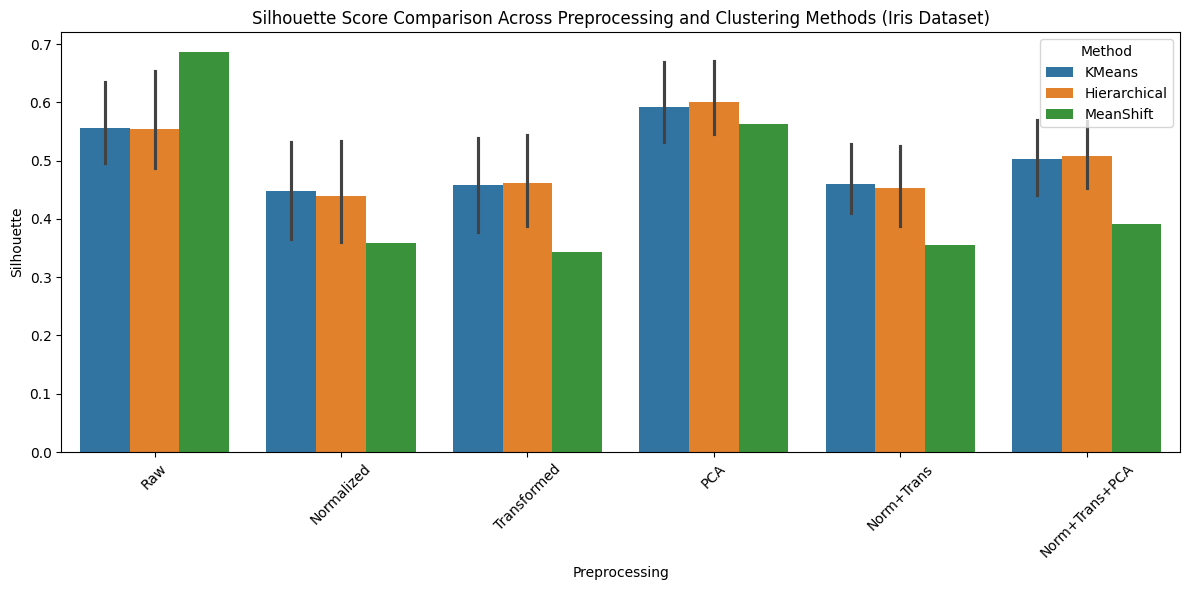

In [ ]:
# # Plot silhouette score comparison
# plt.figure(figsize=(12, 6))
# sns.barplot(data=results_df, x="Preprocessing", y="Silhouette", hue="Method")
# plt.title("Silhouette Score Comparison Across Preprocessing and Clustering Methods (Iris Dataset)")
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()